# Introduction to Quantum Information and Quantum Machine Learning

## Project 4

Mateusz Tabaszewski 151945

## Introduction

This report details the implementation and analysis of Grover's Quantum Search Algorithm.
Grover's algorithm is celebrated for offering a quadratic speedup over classical search methods for unstructured databases. The objective of this project was to develop a simulation of the algorithm, utilizing Qiskit and Python, to explore its operational principles and performance characteristics.

The study focuses on two key aspects of the algorithm's performance:
 - The behavior of the probability of successfully detecting the marked state (pa​) as a function of the number of iterative steps (s), including the demonstration of the optimal number of iterations.
 - The relationship between the final success probability (pa​) and the number of qubits (n), achieved by simulating the algorithm for the optimal number of iterations across a range from n=2 to n=6.

The following sections will cover the theoretical background, the implementation details, the results of the performance simulations, and a concluding analysis.

## Imports

In [1]:
from __future__ import annotations

from typing import (
    Dict,
    List,
    Tuple,
    Any,
    Optional,
    Mapping,
)

import math
import matplotlib.pyplot as plt
import numpy as np
from math import sqrt
from numpy import pi 
from qiskit import QuantumRegister, ClassicalRegister, QuantumCircuit, transpile
from qiskit.quantum_info import Statevector, Operator
from qiskit.circuit.library import XGate
from qiskit.visualization import plot_histogram, plot_distribution
from qiskit_aer import Aer
from time import process_time
from math import floor

In [2]:
backend = Aer.get_backend('unitary_simulator')

## Functions

In [3]:
def plot_results_subplots(
    results_dict: Mapping[Any, Mapping[str, int]],
    probability: bool = False,
    ncols: int = 3,
    figsize: Tuple[int, int] = (14, 8),
    suptitle: Optional[str] = None,
    title_schema: str = "key",
) -> None:
    keys = sorted(results_dict.keys())
    n = len(keys)
    nrows = int(np.ceil(n / ncols))

    fig, axes = plt.subplots(nrows, ncols, figsize=figsize)
    axes = np.array(axes).reshape(nrows, ncols)

    for ax, k in zip(axes.flat, keys):
        data = results_dict[k]
        labels = sorted(data.keys())
        counts = np.array([data[l] for l in labels])

        if probability:
            values = counts / counts.sum()
        else:
            values = counts

        ax.bar(labels, values)
        x = np.arange(len(labels))
        ax.set_title(f"{title_schema} = {k}")
        ax.set_xticks(x)
        ax.set_xticklabels(labels, rotation=90, ha='right')
        y_label = "Probability" if probability else "Count"
        ax.set_ylabel(y_label)

    for i in range(len(keys), nrows*ncols):
        axes.flat[i].axis("off")

    if suptitle:
        fig.suptitle(suptitle, fontsize=16)

    fig.tight_layout()
    plt.show()


In [4]:
def plot_max_probabilities(
    results_dict: Mapping[Any, Mapping[str, int]],
    figsize: Tuple[int, int] = (8, 5),
    title: Optional[str] = None,
    xlabel: str = "Key",
    ylabel: str = "Max Probability",
) -> None:
    keys = sorted(results_dict.keys())
    max_probs = []

    for k in keys:
        counts = np.array(list(results_dict[k].values()))
        max_prob = counts.max() / counts.sum()
        max_probs.append(max_prob)

    plt.figure(figsize=figsize)
    plt.plot(keys, max_probs, marker="o")
    plt.xticks(keys)

    if title:
        plt.title(title)
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)

    plt.grid(True, linestyle="--", alpha=0.5)
    plt.show()


In [5]:
def plot_runtimes(
    runtime_dict: Mapping[Any, float],
    figsize: Tuple[int, int] = (8, 5),
    title: Optional[str] = None,
    xlabel: str = "Key",
    ylabel: str = "Runtime",
) -> None:
    keys = sorted(runtime_dict.keys())
    values = [runtime_dict[k] for k in keys]

    plt.figure(figsize=figsize)
    plt.bar(keys, values)

    if title:
        plt.title(title)
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)

    plt.grid(True, axis="y", linestyle="--", alpha=0.4)
    plt.show()

In [6]:
def calculate_target_number(index: int, n: int) -> int:
    return int(index % (2**n))

In [7]:
def get_optimal_r(n: int) -> int:
    return int(floor((pi/4) * np.sqrt(2**n)))

In [8]:
def get_uf_operator(value: int, n: int) -> Operator:
    oracle=np.identity(2**n)
    oracle[value, value]=-1
    uf=Operator(oracle)
    if not Operator.is_unitary(uf):
        raise ValueError("Unexpected Error, Oracle is not Unitary")
    return uf 

In [9]:
def uf_operator_to_circuit(uf: Operator, n: int) -> Any:
    uf_q = QuantumRegister(n)
    CircuitUf = QuantumCircuit(uf_q, name='Uf')
    CircuitUf.append(uf, uf_q)
    uf_gate = CircuitUf.to_gate()
    return uf_gate

In [10]:
def create_grover_circuit(value: int, n: int, r: int) -> QuantumCircuit:
    if value >= (2**n) or value < 0:
        raise ValueError(f"Invalid search value for the Grover's algorithm, expected: 2**n <= value >= 0, got {value}")

    q = QuantumRegister(n) 
    c = ClassicalRegister(n) 
    grover_circuit = QuantumCircuit(q, c) 
    grover_circuit.h(q)
    grover_circuit.barrier()
    uf = get_uf_operator(value, n)
    uf_gate = uf_operator_to_circuit(uf, n)

    for ii in range(r):
        grover_circuit.append(uf_gate, q)
        grover_circuit.barrier() 
        grover_circuit.h(q)
        grover_circuit.x(q)
        grover_circuit.h(q[-1])
        grover_circuit.mcx(control_qubits=q[:-1], target_qubit=q[-1])
        grover_circuit.h(q[-1])
        grover_circuit.barrier()
        grover_circuit.x(q)
        grover_circuit.h(q)
        grover_circuit.barrier()
    
    grover_circuit.measure(q, c)
    return grover_circuit

In [11]:
def run_grovers_iteration(
    value: int,
    n: int,
    r: int,
    shots: int = 1024
) -> Tuple[float, Dict[str, int]]:
    grovers_circuit = create_grover_circuit(value, n, r)
    t_start = process_time() 
    backend_sim = Aer.get_backend('qasm_simulator')
    transpiled_circuit = transpile(grovers_circuit, backend_sim)
    job_sim = backend_sim.run(transpiled_circuit, shots=shots)
    sim_result = job_sim.result()
    sim_counts = sim_result.get_counts(grovers_circuit)
    t_stop = process_time()
    run_time = t_stop - t_start
    return run_time, sim_counts

In [12]:
def run_grovers(
    value: int,
    n: int,
    rs: List[int],
    shots: int = 1024
) -> Tuple[Dict[int, float], Dict[int, Dict[str, int]]]:
    times_dict = {}
    counts_dict = {}
    for curr_r in rs:
        curr_time, curr_counts = run_grovers_iteration(value=value,
                                                       n=n,
                                                       r=curr_r,
                                                       shots=shots)
        counts_dict[curr_r] = curr_counts
        times_dict[curr_r] = curr_time
    return times_dict, counts_dict

## Task 1

In [13]:
ns = range(2, 7)
for n in ns:
    r = get_optimal_r(n)
    print(f"For n = {n} Optimal Value of r = {r}")

For n = 2 Optimal Value of r = 1
For n = 3 Optimal Value of r = 2
For n = 4 Optimal Value of r = 3
For n = 5 Optimal Value of r = 4
For n = 6 Optimal Value of r = 6


## Task 2

### Example Grover's Circuit for n = 3

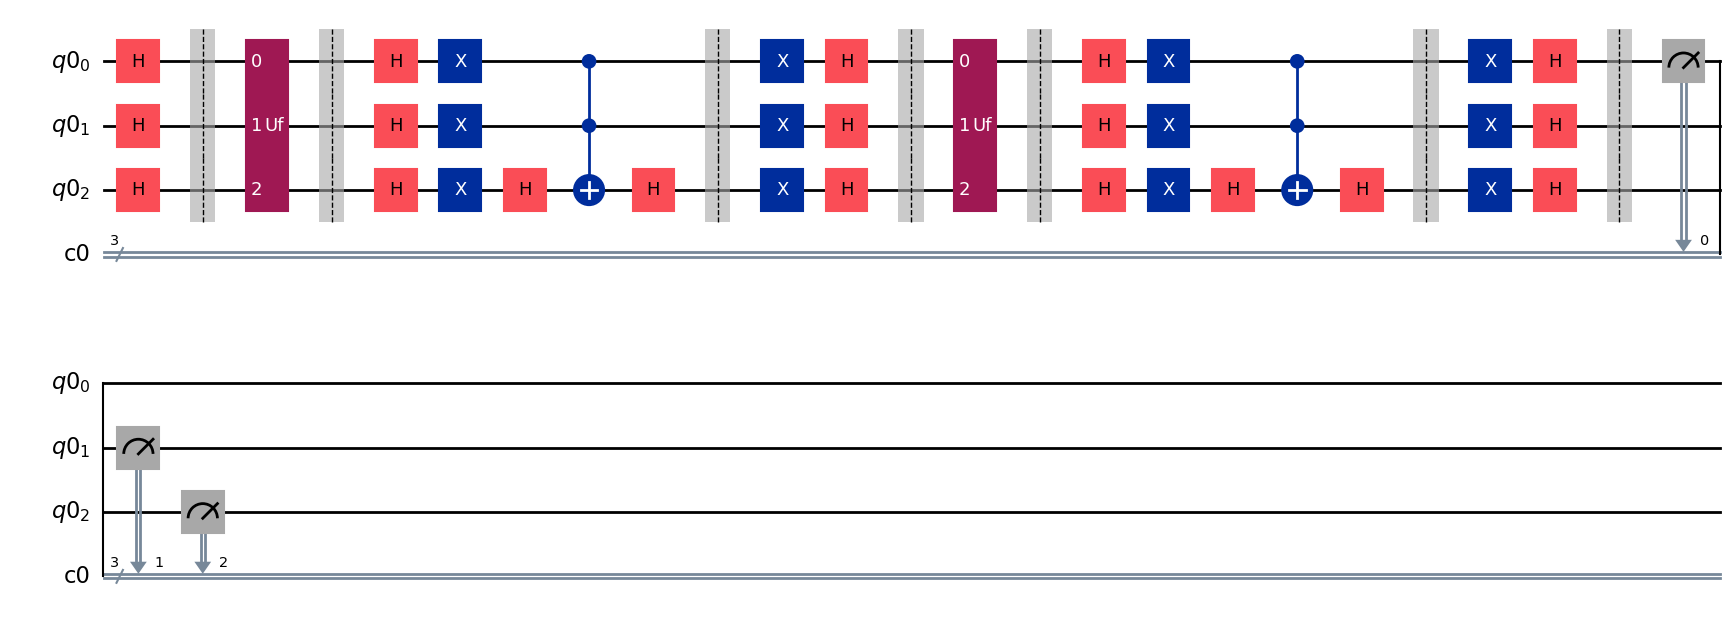

In [14]:
n = 3
r = get_optimal_r(n)
value = 2

test_circuit_1 = create_grover_circuit(value, n, r)
test_circuit_1.draw(output='mpl')


### Example Grover's Circuit for n = 4

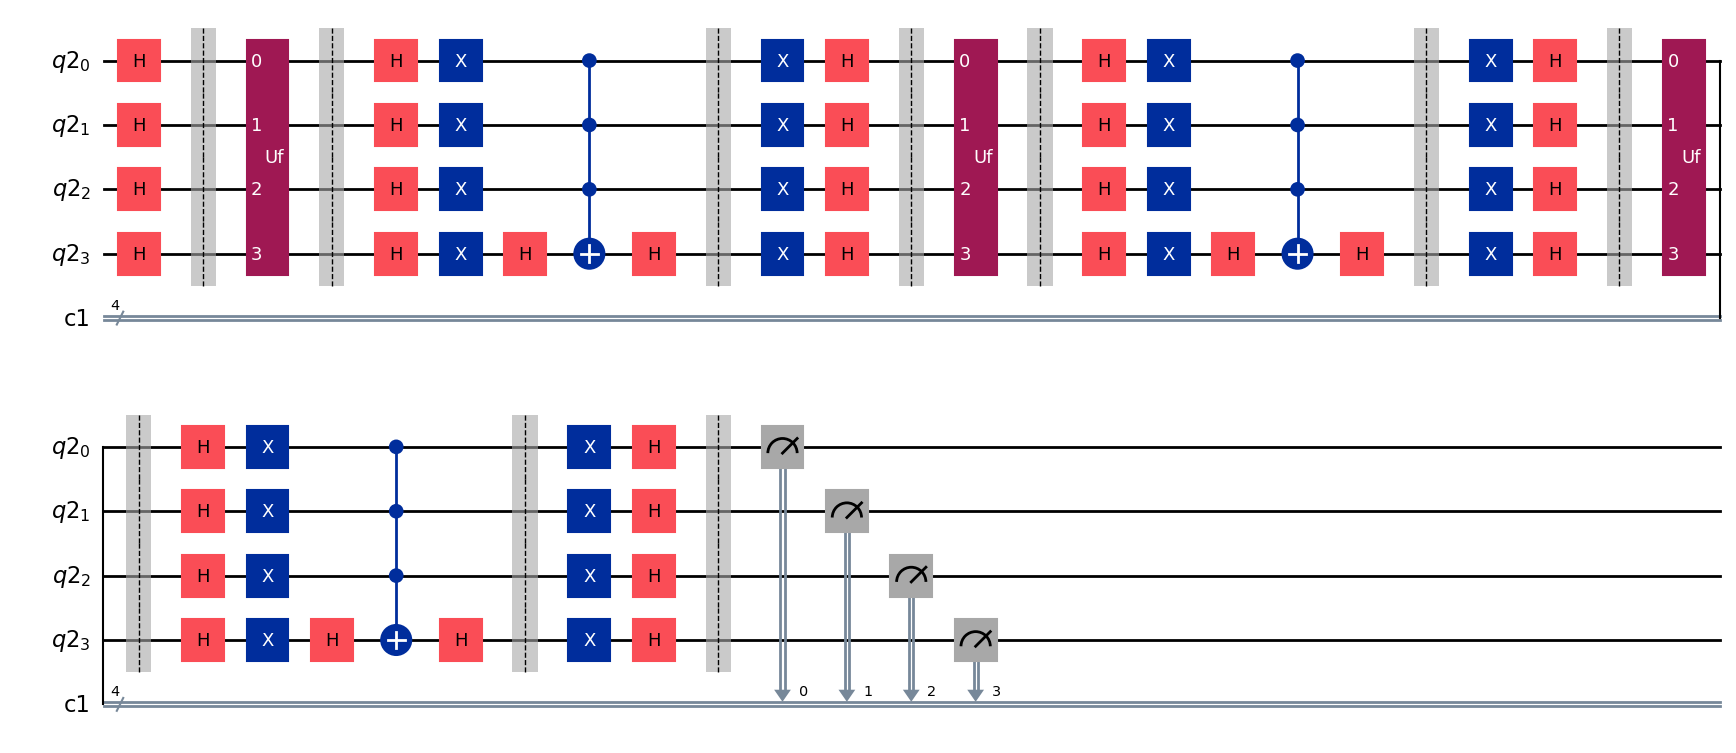

In [15]:
n = 4
r = get_optimal_r(n)
value = 2

test_circuit_2 = create_grover_circuit(value, n, r)
test_circuit_2.draw(output='mpl')


## Task 3

In [16]:
n = 6
index_number = 151945

target_value = calculate_target_number(index_number, n)
print(f"Target Value: {target_value}")

Target Value: 9


In [17]:
n = 6
r = get_optimal_r(n)
rs = range(1, r+1)

results_times, results_counts = run_grovers(target_value, n, rs)

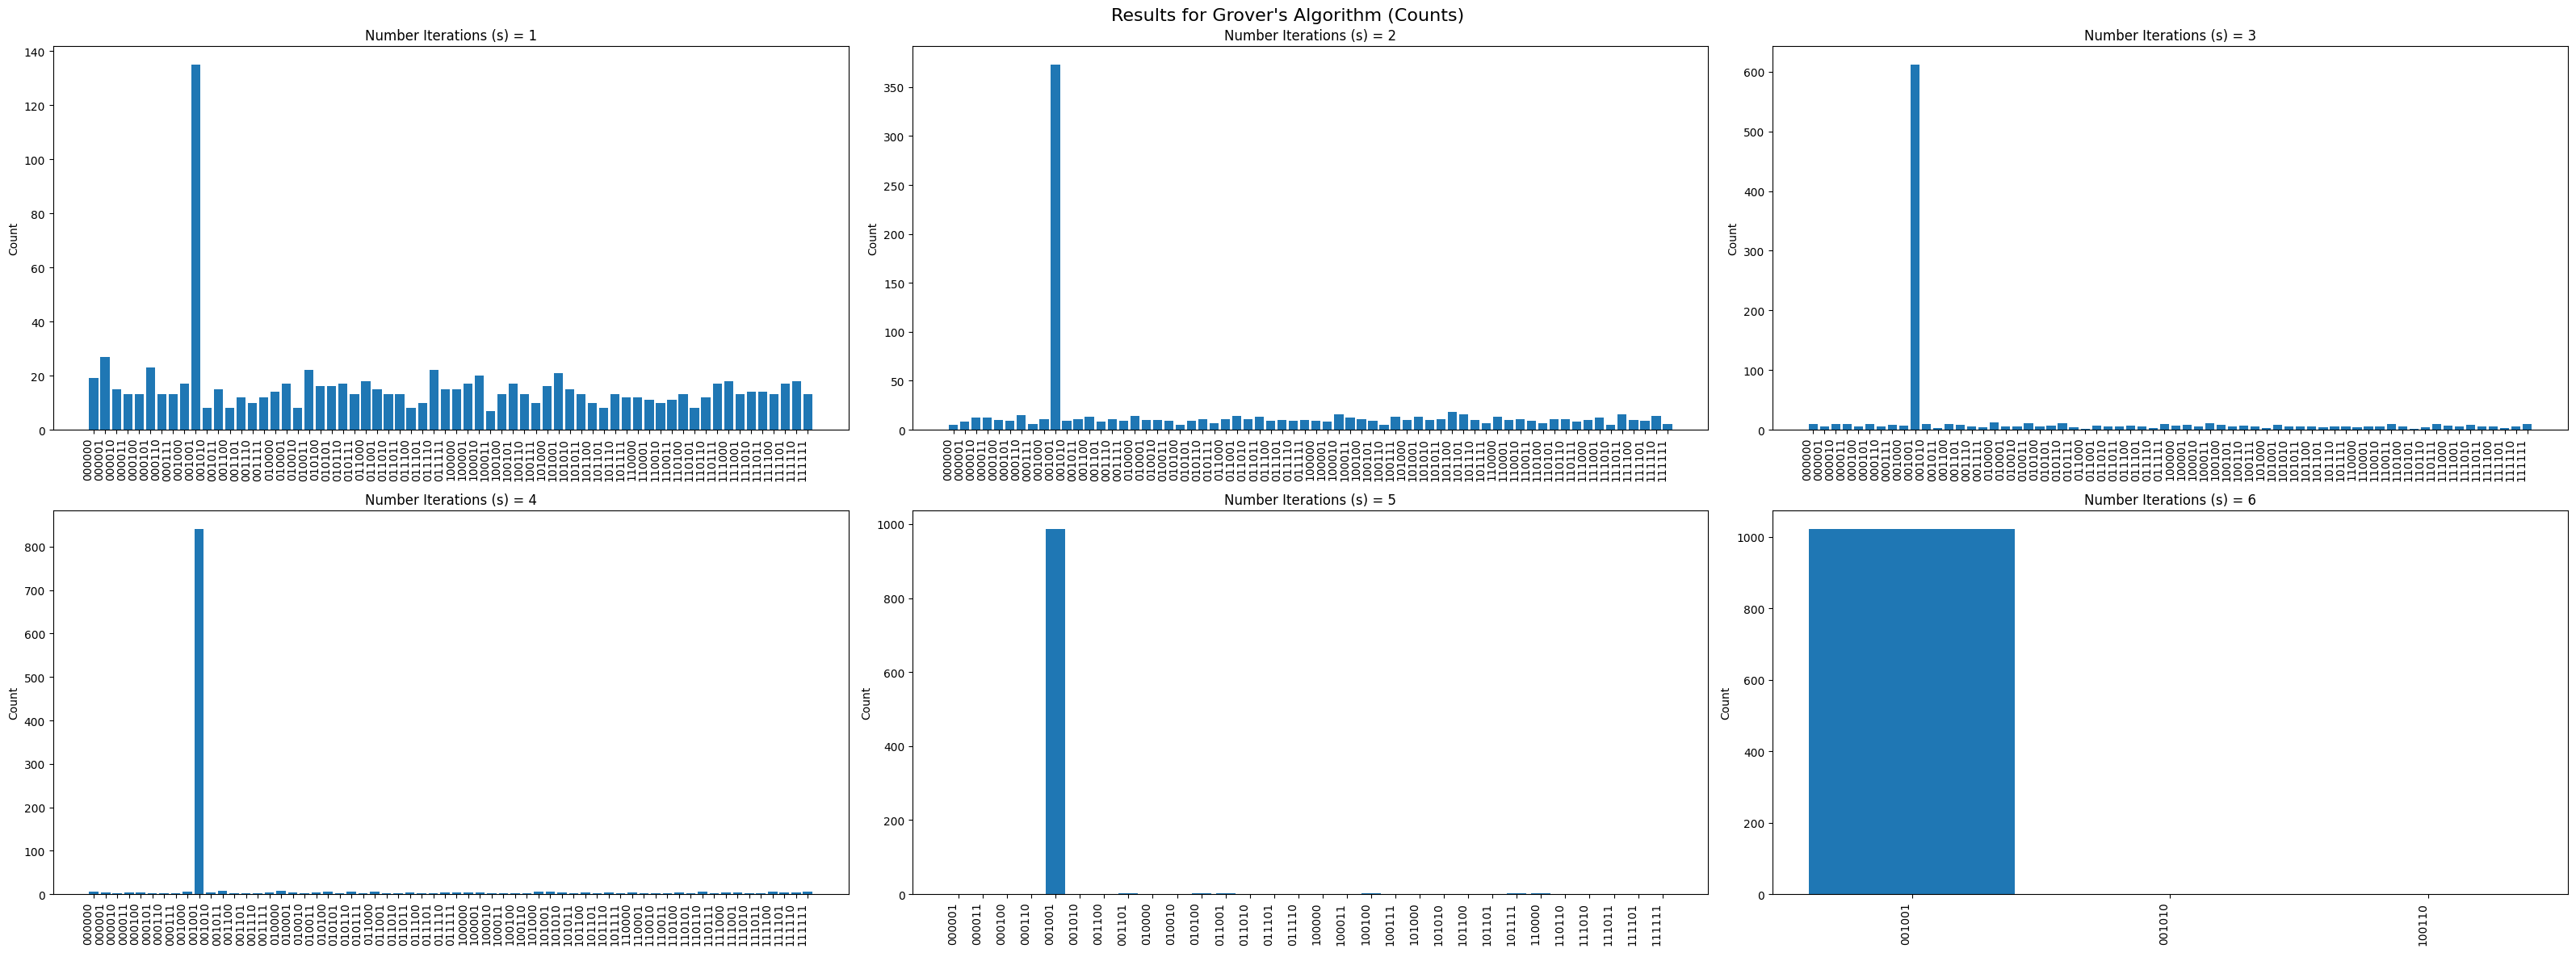

In [18]:
plot_results_subplots(results_counts,
                      probability=False,
                      ncols=3,
                      figsize=(32, 12),
                      suptitle="Results for Grover's Algorithm (Counts)",
                      title_schema="Number Iterations (s)")

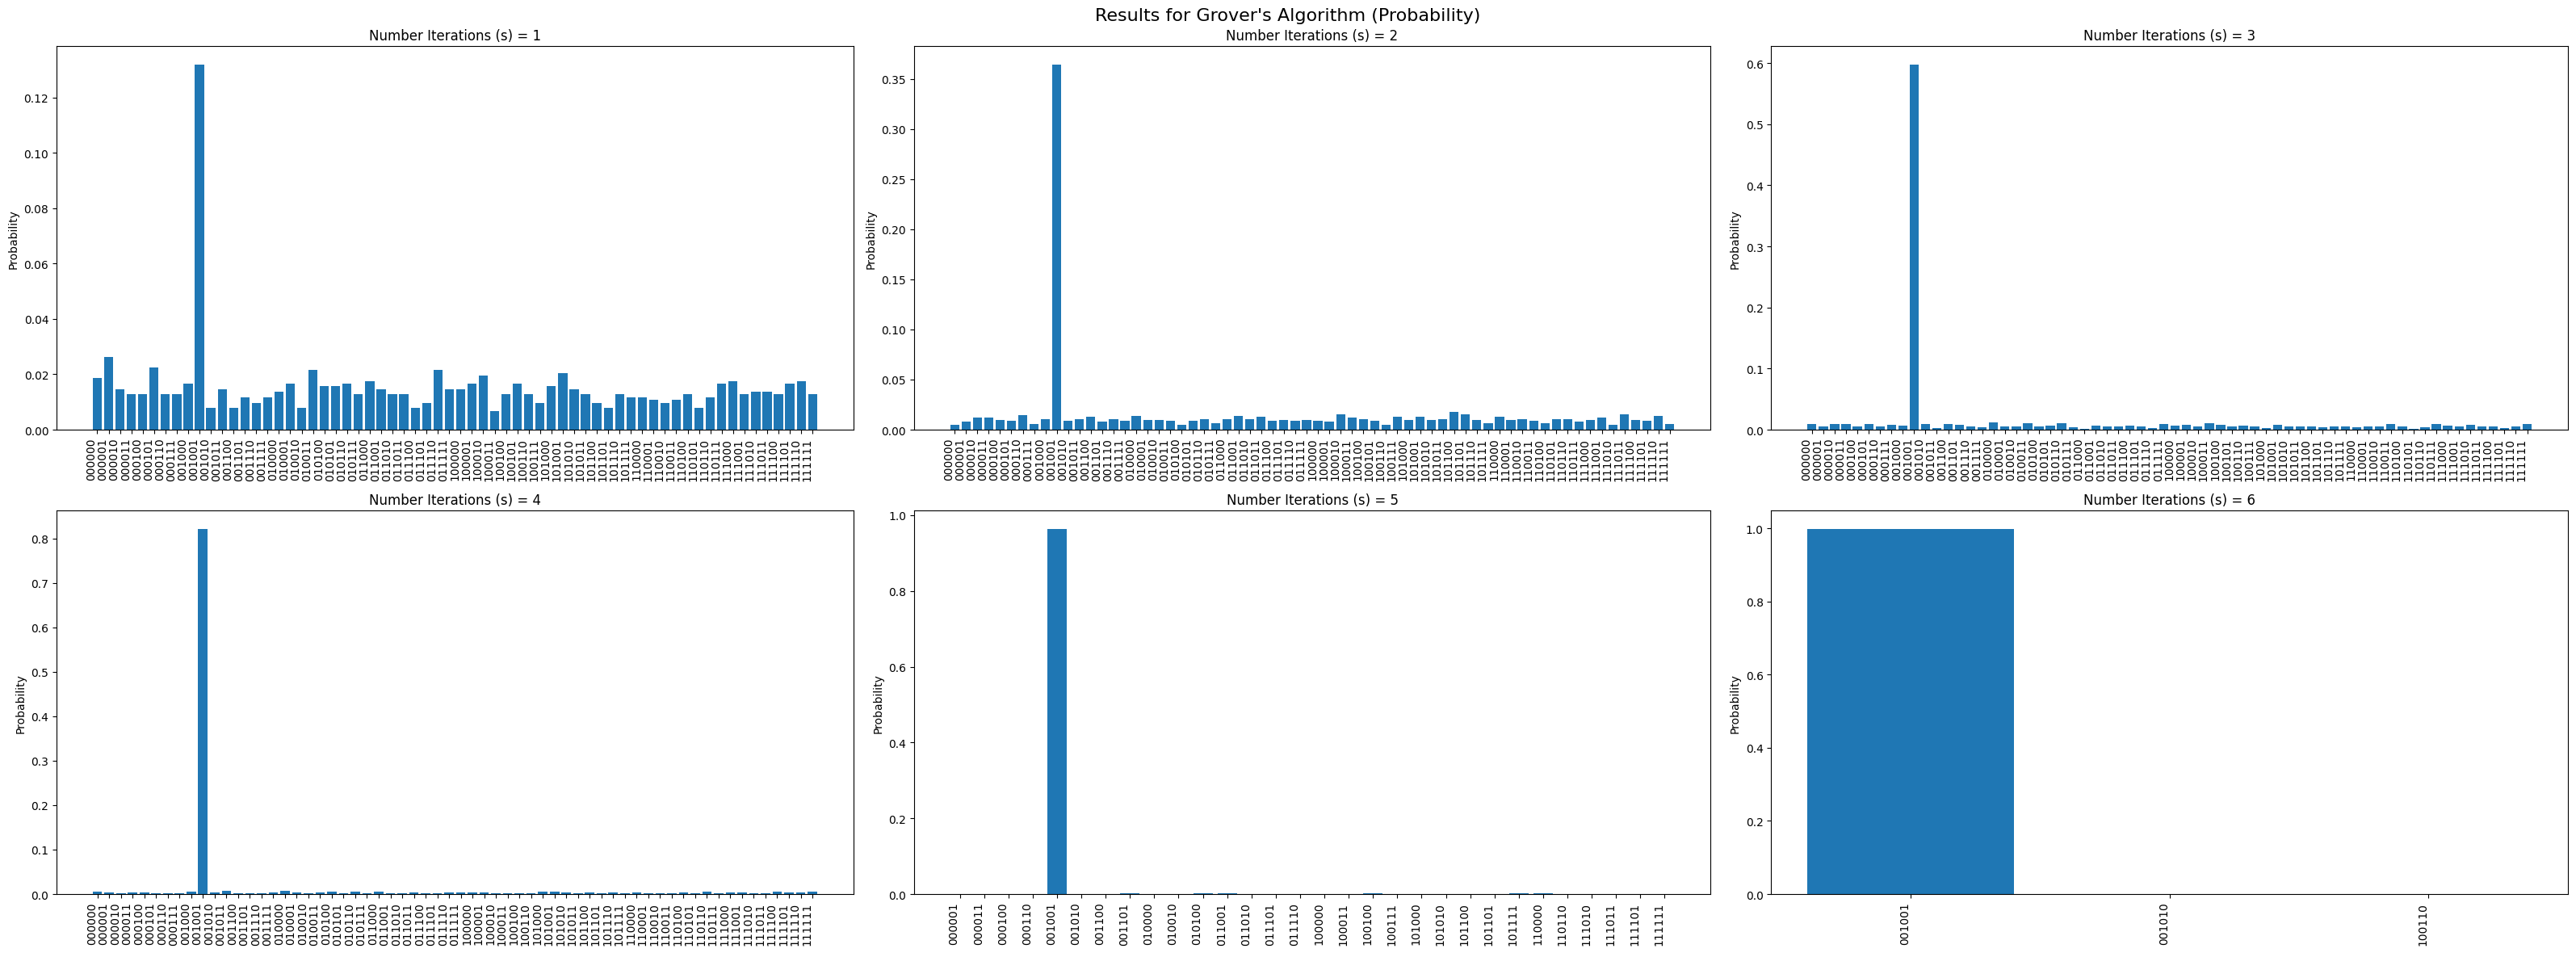

In [19]:
plot_results_subplots(results_counts,
                      probability=True,
                      ncols=3,
                      figsize=(32, 12),
                      suptitle="Results for Grover's Algorithm (Probability)",
                      title_schema="Number Iterations (s)")

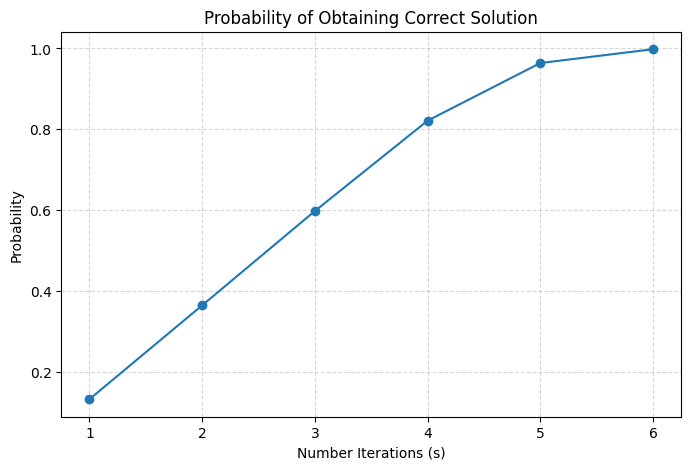

In [20]:
plot_max_probabilities(results_counts,
                       figsize=(8, 5),
                       title="Probability of Obtaining Correct Solution",
                       xlabel="Number Iterations (s)",
                       ylabel="Probability")

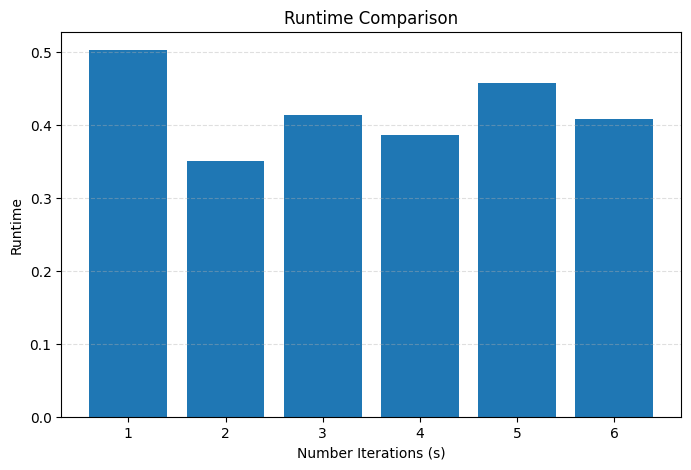

In [21]:
plot_runtimes(results_times,
              figsize=(8, 5),
              title="Runtime Comparison",
              xlabel="Number Iterations (s)",
              ylabel="Runtime")

## Task 4

In [22]:
n = 6
r = get_optimal_r(n)
rs = range(1, 2*r+1)

results_times, results_counts = run_grovers(target_value, n, rs)

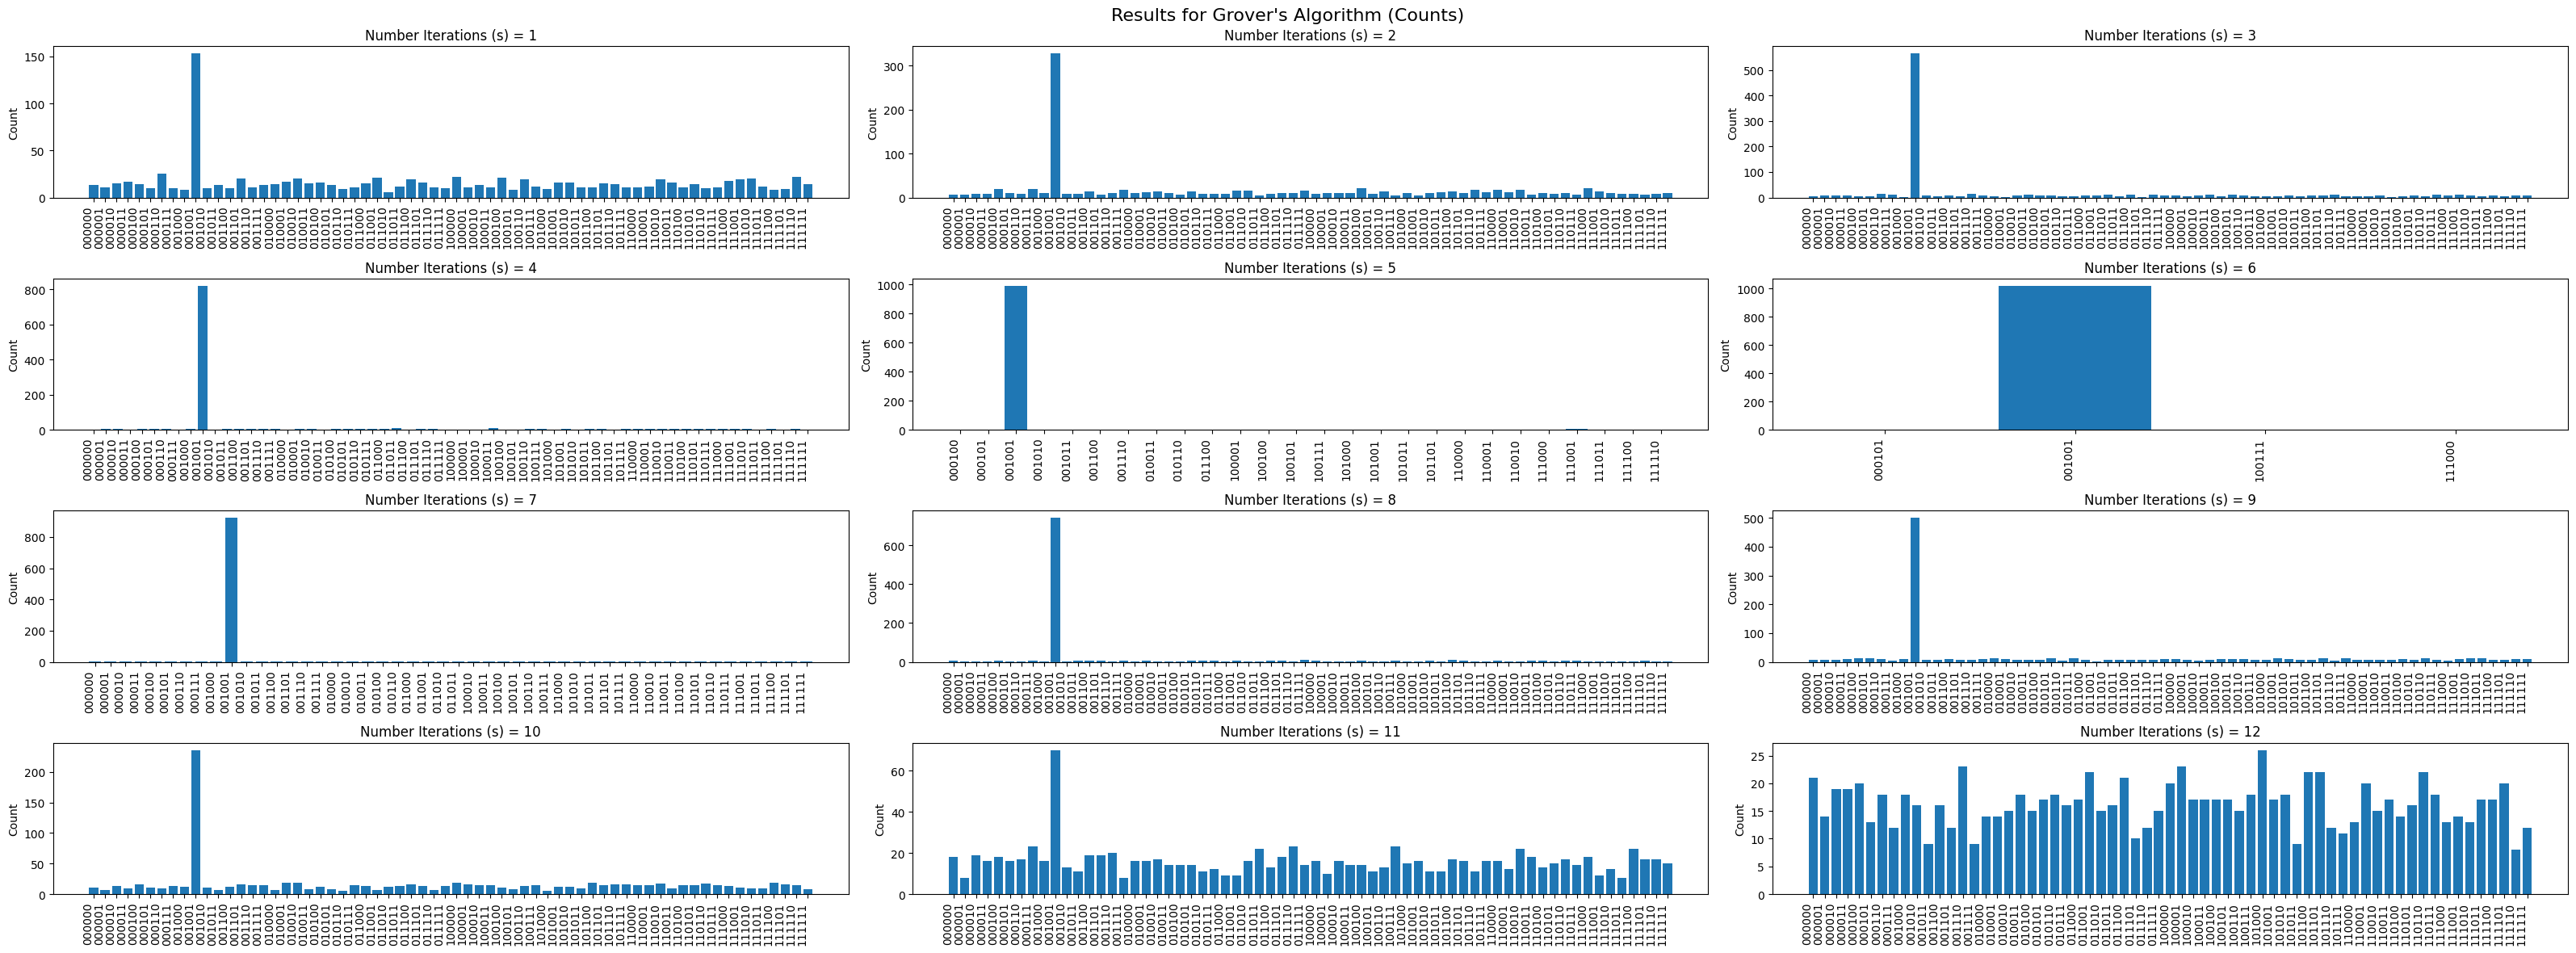

In [23]:
plot_results_subplots(results_counts,
                      probability=False,
                      ncols=3,
                      figsize=(32, 12),
                      suptitle="Results for Grover's Algorithm (Counts)",
                      title_schema="Number Iterations (s)")

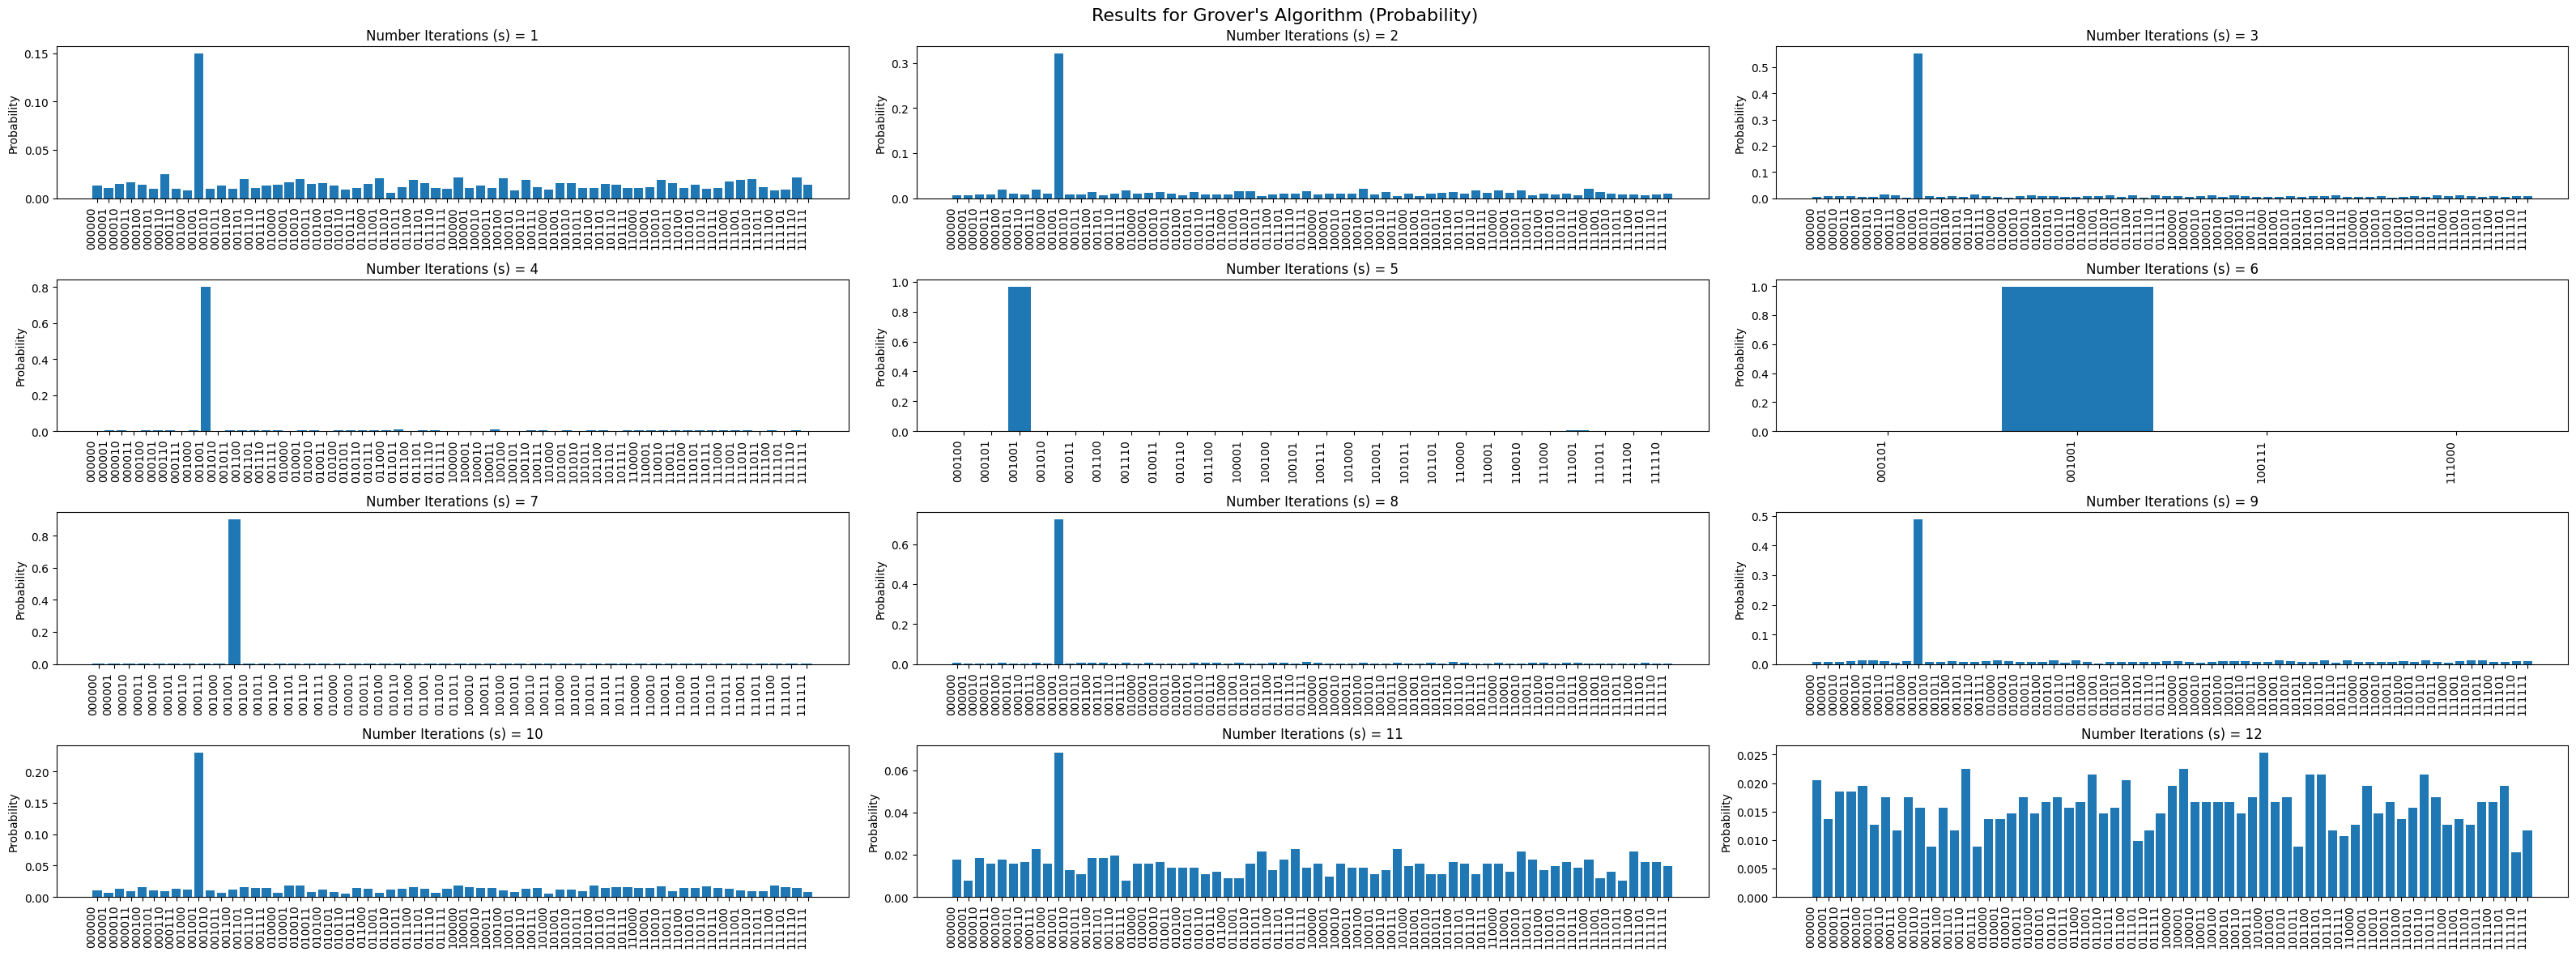

In [24]:
plot_results_subplots(results_counts,
                      probability=True,
                      ncols=3,
                      figsize=(32, 12),
                      suptitle="Results for Grover's Algorithm (Probability)",
                      title_schema="Number Iterations (s)")

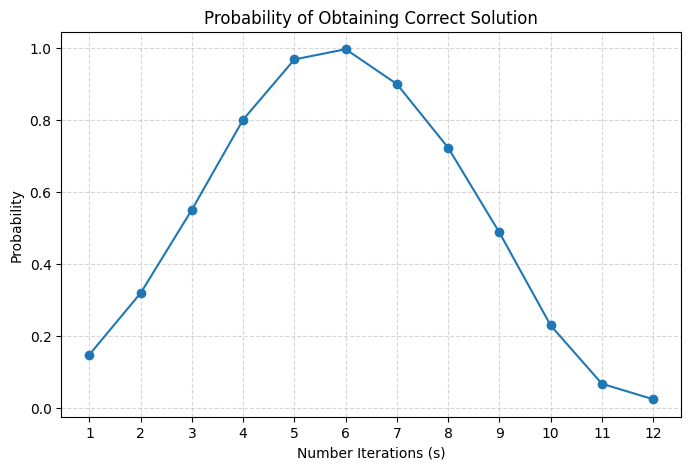

In [25]:
plot_max_probabilities(results_counts,
                       figsize=(8, 5),
                       title="Probability of Obtaining Correct Solution",
                       xlabel="Number Iterations (s)",
                       ylabel="Probability")

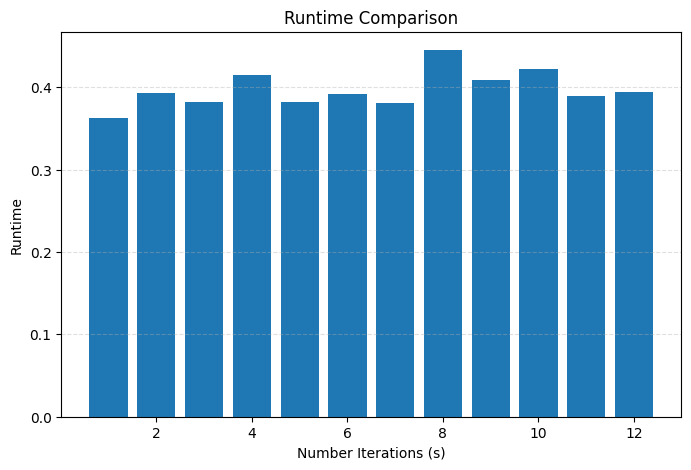

In [26]:
plot_runtimes(results_times,
              figsize=(8, 5),
              title="Runtime Comparison",
              xlabel="Number Iterations (s)",
              ylabel="Runtime")

## Task 5

In [27]:
ns = range(2, 7)
index_number = 151945
result_counts = {}
result_times = {}

for n in ns:
    target_value = calculate_target_number(index_number, n)
    print(f"For n = {n} Target Value: {target_value}")
    target_r = get_optimal_r(n)
    curr_time, curr_counts = run_grovers_iteration(target_value, n, target_r)
    result_counts[n] = curr_counts
    result_times[n] = curr_time

For n = 2 Target Value: 1
For n = 3 Target Value: 1
For n = 4 Target Value: 9
For n = 5 Target Value: 9
For n = 6 Target Value: 9


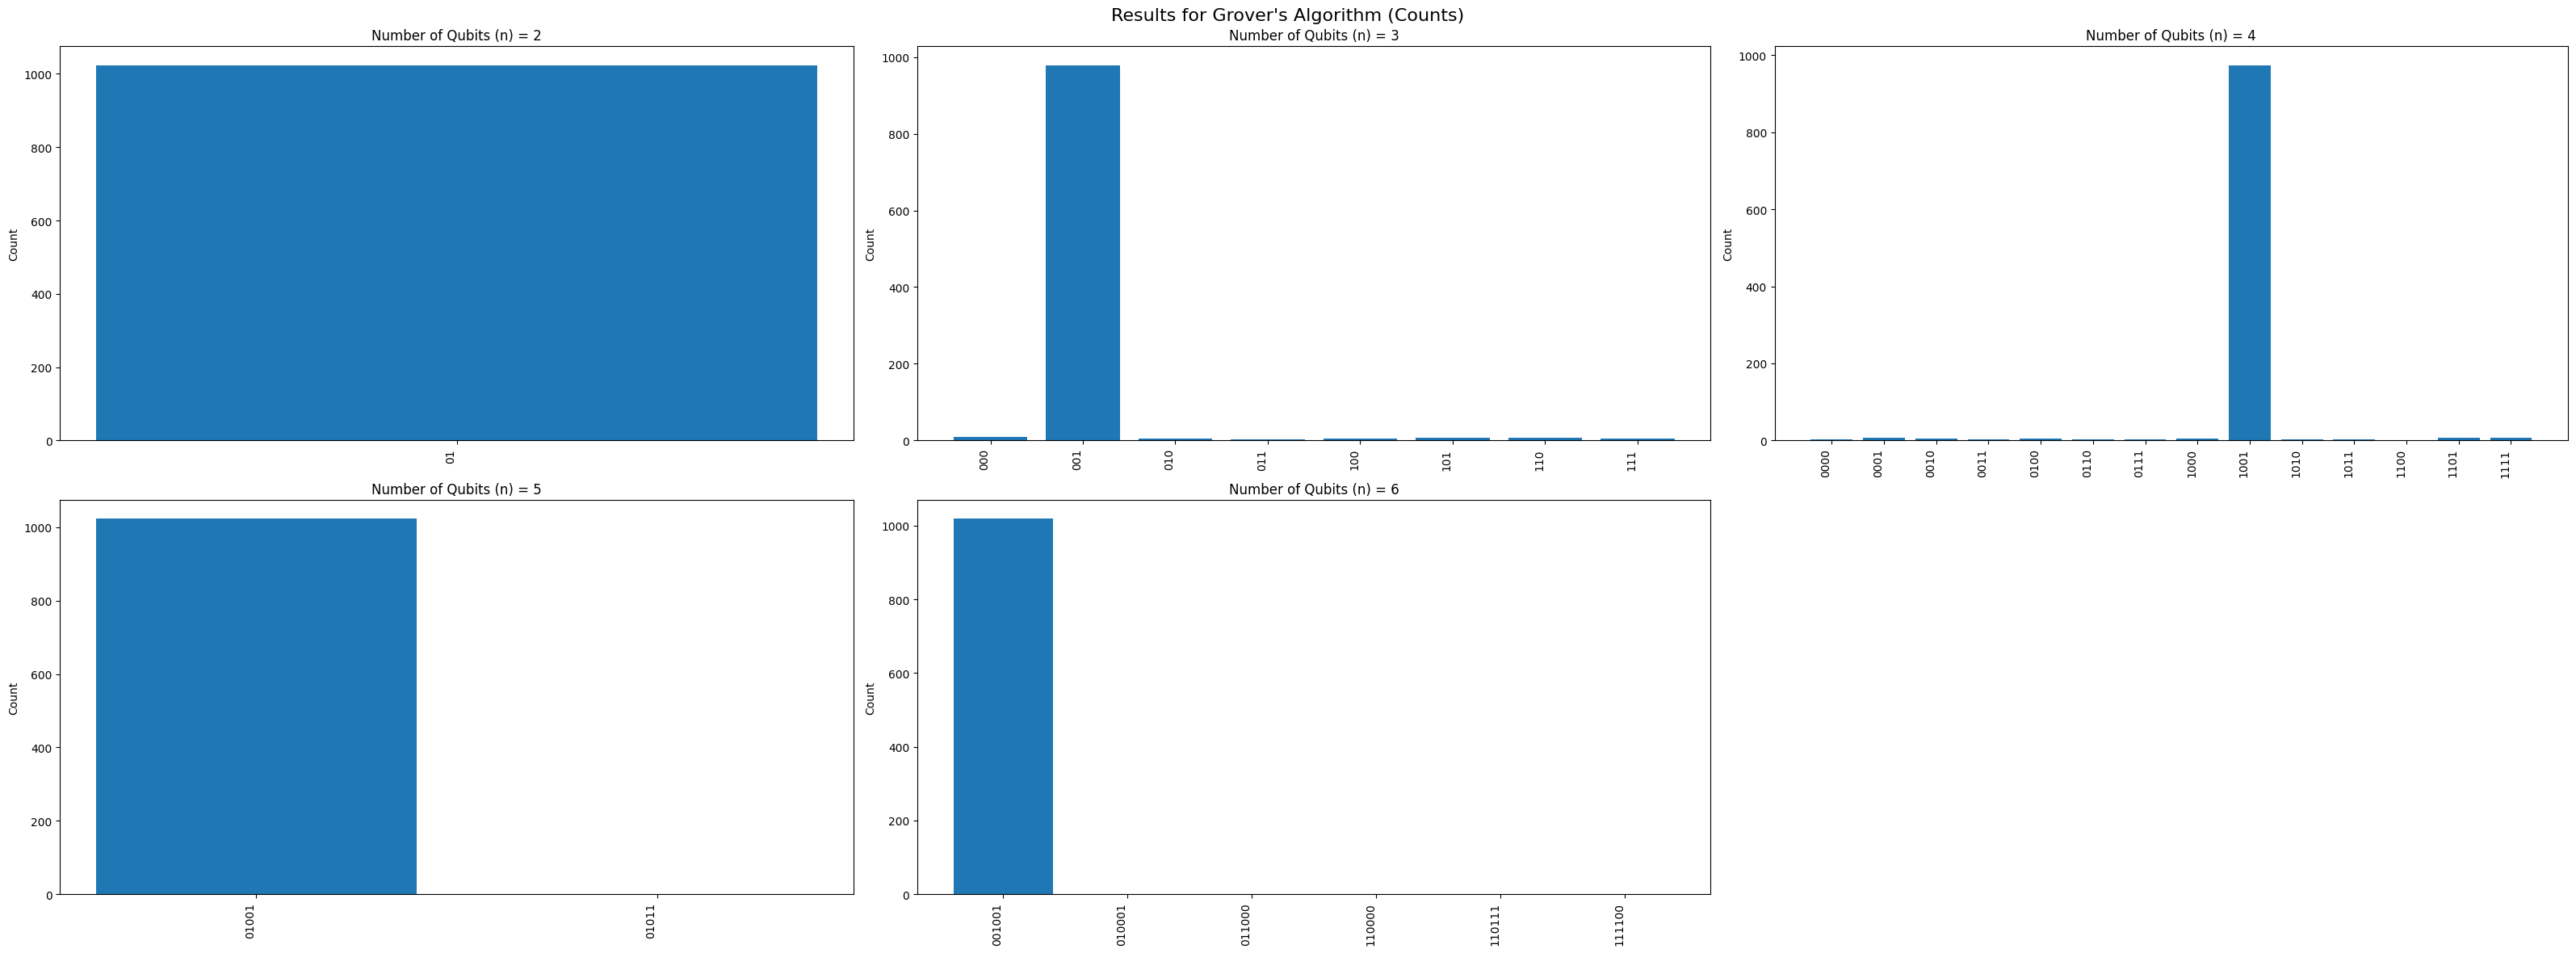

In [28]:
plot_results_subplots(result_counts,
                      probability=False,
                      ncols=3,
                      figsize=(32, 12),
                      suptitle="Results for Grover's Algorithm (Counts)",
                      title_schema="Number of Qubits (n)")

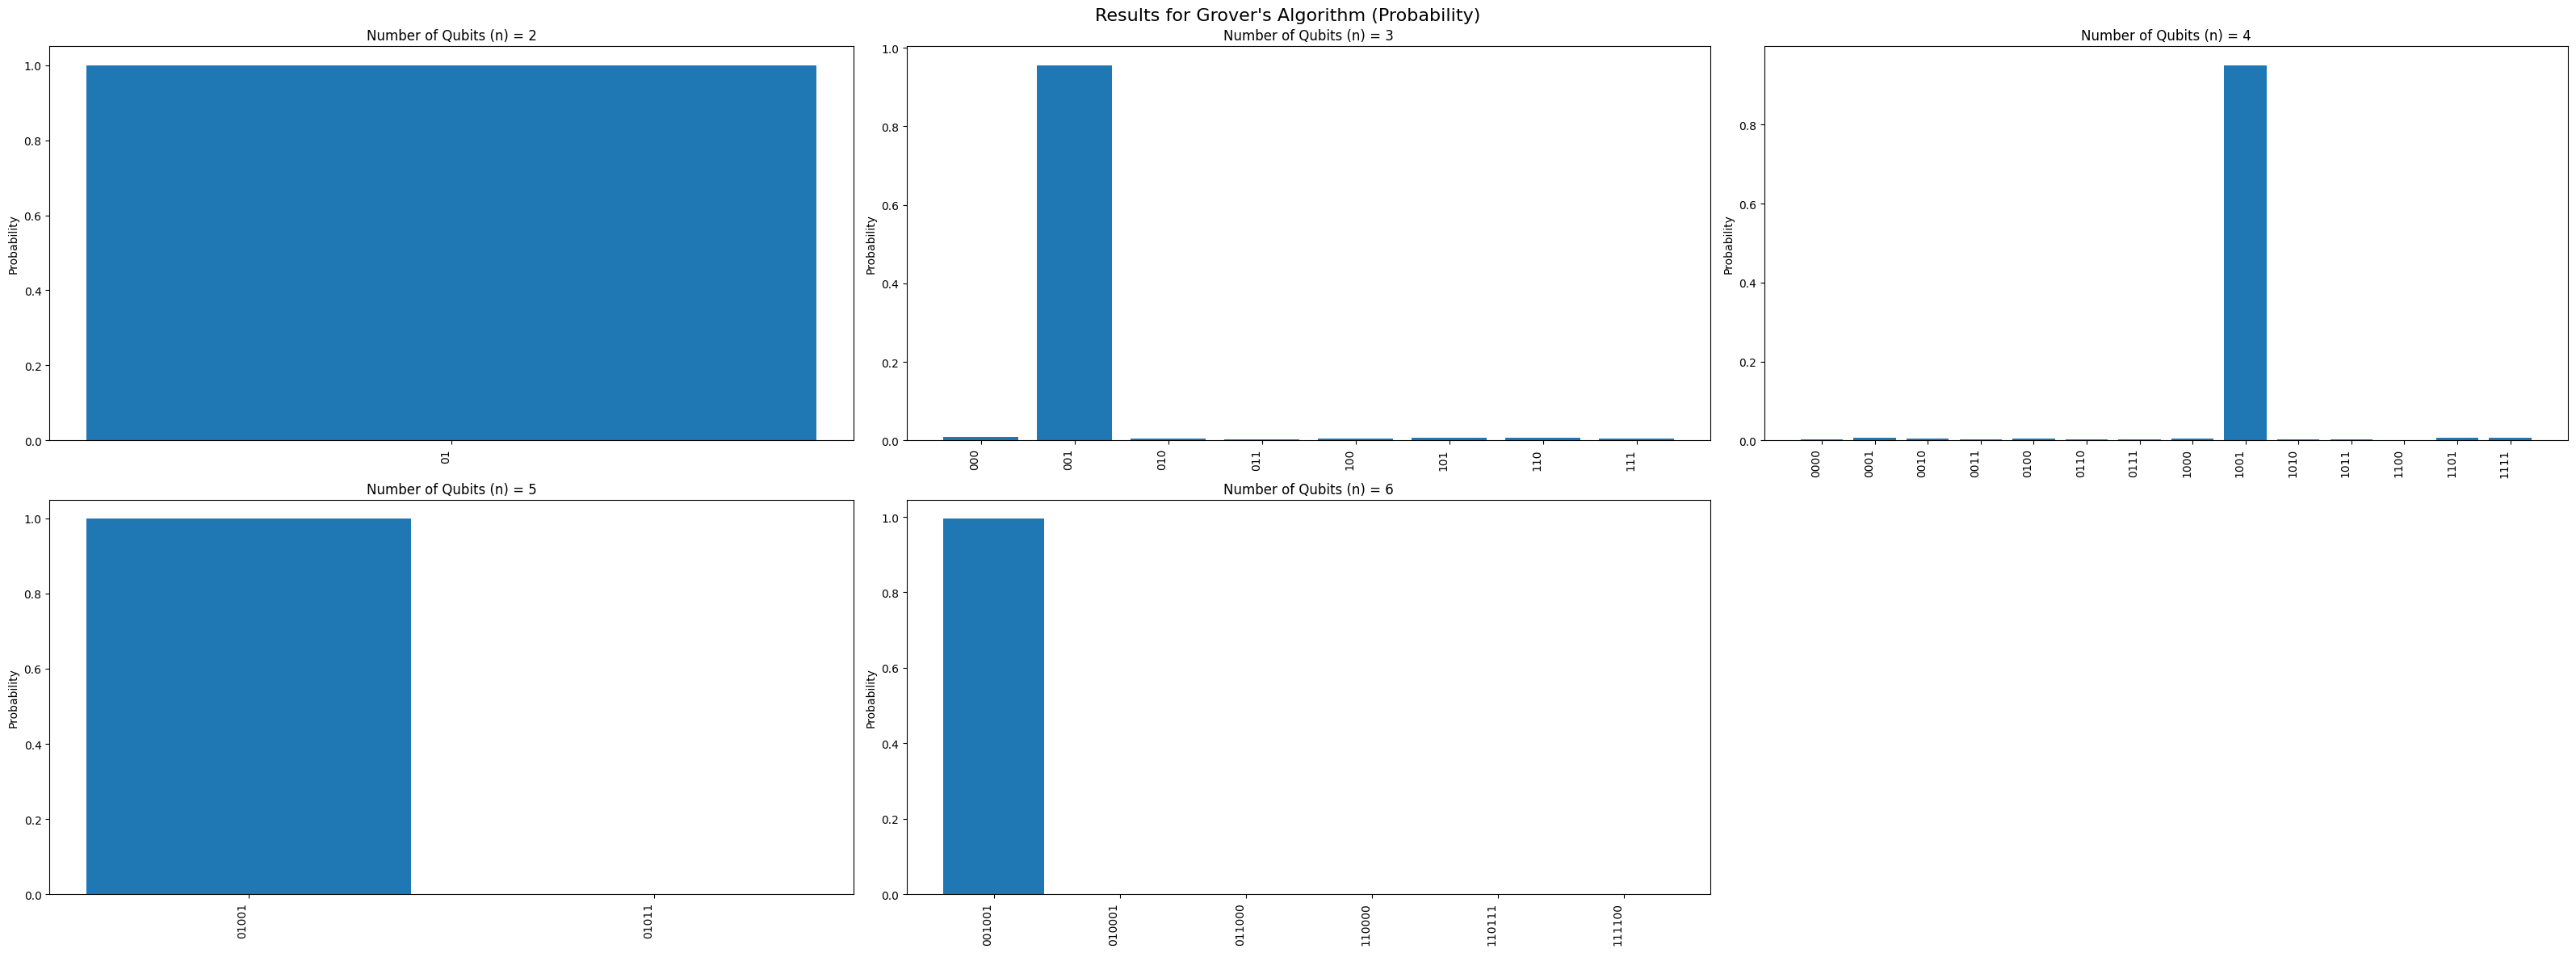

In [29]:
plot_results_subplots(result_counts,
                      probability=True,
                      ncols=3,
                      figsize=(32, 12),
                      suptitle="Results for Grover's Algorithm (Probability)",
                      title_schema="Number of Qubits (n)")

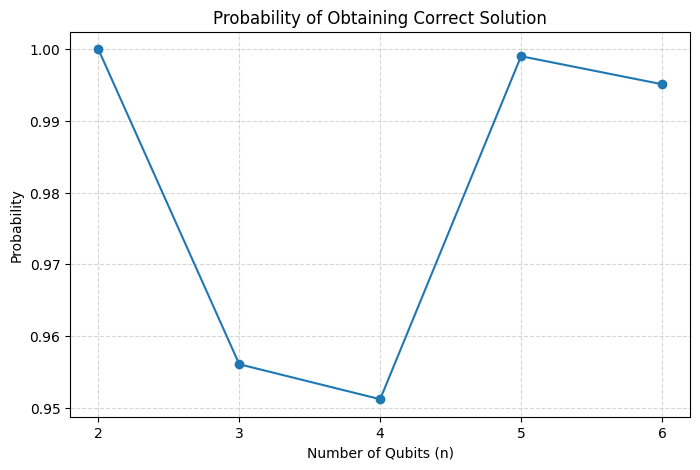

In [30]:
plot_max_probabilities(result_counts,
                       figsize=(8, 5),
                       title="Probability of Obtaining Correct Solution",
                       xlabel="Number of Qubits (n)",
                       ylabel="Probability")

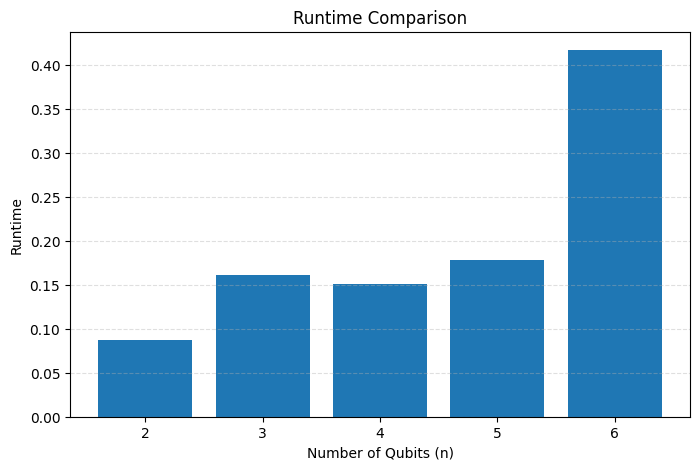

In [31]:
plot_runtimes(result_times,
              figsize=(8, 5),
              title="Runtime Comparison",
              xlabel="Number of Qubits (n)",
              ylabel="Runtime")

## Conclusions

The report showcased and implemented a working Grover's Algorithm using a phase oracle. The solution showed that picking the correct numebr of iterations is crucial as the distribution of probabilities of finding correct value has "bell-like" curve shape. In conclusion, the Grover's algorithm can be used to find elements in a list within square root time complexity, allowing for speed up when compared against classical, linear-time algorithms.